This is the tutorial for the evaluation of CPHF alchemical derivatives using PySCF (version 2.2)

In [1]:
from pyscf import gto,scf
import numpy as np
import pyscf
import matplotlib.pyplot as plt
import basis_set_exchange as bse
import os
import glob

pyscf.__version__

'2.2.1'

## Fractional charge molecules

In [2]:
from FcMole import FcM, FcM_like

In [3]:
mol_NN=gto.M(atom= "N 0 0 0; N 0 0 2.1",unit="Bohr", basis="def2-TZVP")

The FcM_like function creates a copy of a givem PySCF molecule object with modified nuclear cherges 

In [4]:
fmol1=FcM_like(mol_NN,fcs=[.1,-.1])

Only nuclear charges are modified, the number of electrons stays the same

In [5]:
fmol1.atom_charges(),fmol1.nelec

(array([7.1, 6.9]), (7, 7))

The same result can be achieved using the FcM constructor

In [6]:
fmol2=FcM(fcs=[.2,-.2],atom= "N 0 0 0; N 0 0 2.1",unit="Bohr", basis="def2-TZVP")

The number of electron matches the atom string

In [7]:
fmol2.atom_charges(),fmol2.nelec

(array([7.2, 6.8]), (7, 7))

If only some atoms have modified nuclear charges is possible to pass as a fcs parameter a double list [[idxs],[fcs]]

In [8]:
fmol3=FcM(fcs=[[0,1],[.3,-.3]],atom= "N 0 0 0; N 0 0 2.1",unit="Bohr", basis="def2-TZVP")

In [9]:
fmol3.atom_charges(),fmol3.nelec

(array([7.3, 6.7]), (7, 7))

For scf calculations using fractional charges molecules the initial density matrix guess needs to be evaluated from the eigenfunction of the monoelectronic Hamiltonian (there is no single atom density "SAD" matrix guess for atoms with fractional charge)

In [10]:
mf=scf.RKS(mol_NN)
mf1=scf.RKS(fmol1)
mf2=scf.RKS(fmol2)
mf3=scf.RKS(fmol3)

The KS-DFT functional is specified. Here, the PBE0 functional is used.

In [11]:
mf.xc = 'pbe0'
mf1.xc = 'pbe0'
mf2.xc = 'pbe0'
mf3.xc = 'pbe0'

In [12]:
e=mf.scf(dm0=mf.init_guess_by_1e())
e1=mf1.scf(dm0=mf1.init_guess_by_1e())
e2=mf2.scf(dm0=mf2.init_guess_by_1e())
e3=mf3.scf(dm0=mf3.init_guess_by_1e())

converged SCF energy = -109.444982309111


/home/takafumi/program/pyscf/pyscf/gto/mole.py:1213: UserWarning: Function mol.dumps drops attribute with_rinv_at_nucleus because it is not JSON-serializable
  warnings.warn(msg)


converged SCF energy = -109.481953806731
converged SCF energy = -109.592853975726
converged SCF energy = -109.777639934063


for small basis sets the scf does not converge to the true minimum -> using initial guess from previous step enforces it 


In [13]:
# mf1.scf(dm0=mf.make_rdm1())
# mf2.scf(dm0=mf1.make_rdm1())
# mf3.scf(dm0=mf2.make_rdm1())

Checking wavefunction convergence from the nuclear gradient

In [14]:
mf.nuc_grad_method().kernel()
mf1.nuc_grad_method().kernel()
mf2.nuc_grad_method().kernel()
mf3.nuc_grad_method().kernel()

--------------- RKS gradients ---------------
         x                y                z
0 N     0.0000000000    -0.0000000000    -0.0623740387
1 N    -0.0000000000     0.0000000000     0.0623740387
----------------------------------------------
--------------- RKS gradients ---------------
         x                y                z
0 N    -0.0000000000    -0.0000000000    -0.0614786766
1 N     0.0000000000     0.0000000000     0.0614779593
----------------------------------------------
--------------- RKS gradients ---------------
         x                y                z
0 N     0.0000000000    -0.0000000000    -0.0587971284
1 N     0.0000000000     0.0000000000     0.0587957831
----------------------------------------------
--------------- RKS gradients ---------------
         x                y                z
0 N     0.0000000000    -0.0000000000    -0.0543453247
1 N    -0.0000000000     0.0000000000     0.0543435338
----------------------------------------------


array([[ 1.75326866e-15, -2.51117840e-16, -5.43453247e-02],
       [-1.05390259e-15,  3.54232126e-17,  5.43435338e-02]])

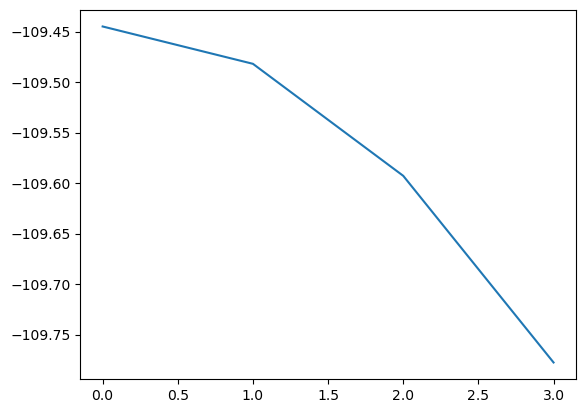

In [15]:
plt.plot([e,e1,e2,e3]) # the potential 

Remove temporary files generated by PySCF

In [16]:
# for filename in glob.glob('tmp*'):
#     os.remove(filename)

## Using the Alchemical Perturbator (AP) class
We created an Alchemical perturbator object to access easily all the CPHF methods for alchemical derivative and alchemical forces derivatives, this allow us to save the derivatives and also to exploit the symmetry of the system

In [17]:
%load_ext autoreload
%autoreload 2
from AP_class import APDFT_perturbator as AP

In [18]:
# mol_NN_pcX2=gto.M(atom= "N 0 0 0; N 0 0 2.1",unit="Bohr",basis=bse.get_basis('pcX-2',fmt="nwchem",elements=[6,7,8]))
mol_NN_pcX2=gto.M(atom= "N 0 0 0; N 0 0 2.1",unit="Bohr",basis="def2-TZVP")

The alchemical perturbator is instantiated from a converged RHF object, and for some given perturbation sites.

In [19]:
mf_nn=scf.RKS(mol_NN_pcX2)
mf_nn.xc = 'pbe0'
# mf_nn.xc = 'lda,vwn'
mf_nn.scf()
# mf_nn.nuc_grad_method().kernel()
ap_nn=AP(mf_nn,sites=[0,1])

converged SCF energy = -109.444982314726


Alchemical gradient $ \partial E/\partial Z_i $, hessian $\partial^2E/\partial Z_i\partial Z_j$ and cubic hessian $\partial^3E/\partial Z_i\partial Z_j\partial Z_k$can be obtained from their buid functions 


In [20]:
#build the alchemical gradient dE/dZ_i
ap_nn.build_gradient()

array([-18.30433514, -18.30433514])

In [21]:
#build the alchemical hessian d**2E/dZ_i/dZ_j
ap_nn.build_hessian()

array([[-3.22401998,  0.47324897],
       [ 0.47324897, -3.22401998]])

In [22]:
ap_nn.build_cubic_hessian()

array([[[-0.2032581 ,  0.11237206],
        [ 0.11237206,  0.11237206]],

       [[ 0.11237206,  0.11237206],
        [ 0.11237206, -0.2032581 ]]])

Are saved inside the class and can be accessed in a later moment

In [23]:
ap_nn.gradient,ap_nn.hessian,ap_nn.cubic_hessian

(array([-18.30433514, -18.30433514]),
 array([[-3.22401998,  0.47324897],
        [ 0.47324897, -3.22401998]]),
 array([[[-0.2032581 ,  0.11237206],
         [ 0.11237206,  0.11237206]],
 
        [[ 0.11237206,  0.11237206],
         [ 0.11237206, -0.2032581 ]]]))

Alchemical perturbations for isolelectronic transmutations can be calculated from the derivatives up to order 3

In [24]:
ap_nn.APDFT1(np.asarray([-1,0])) # to CN-

-91.14064717553961

In [25]:
ap_nn.APDFT2(np.asarray([-1,1])) # to CO

-113.142251264782

In [26]:
ap_nn.APDFT3(np.asarray([0,1]))  # to NO+

-129.39520379234105

In [27]:
ap_nn.APDFT3(np.asarray([1,1])) # to OO++

-148.75980424112808

## Alchemical forces
Alchemical forces are calculated resusing the density matrix derivatives already evaluated. The function af(I) gives the alchemical force of the atom $I$ : $\partial \mathbf{g}/ \partial Z_I$ [2]


In [28]:
ap_nn.af(0),ap_nn.af(1)

(array([[ 7.69076224e-16,  3.23315280e-15, -1.80313662e-01],
        [ 2.48679190e-16, -2.76259809e-15,  1.65182126e-01]]),
 array([[ 1.04794817e-15, -2.43816072e-15, -1.65182126e-01],
        [-5.51558730e-16,  1.06617690e-15,  1.80313662e-01]]))

Inefficient alchemical force in KS-DFT which calculates the response matrix for nuclear coordinates

In [29]:
ap_nn.build_inefficient_alchemical_force(0), ap_nn.build_inefficient_alchemical_force(1)

(array([[ 2.48153689e-16,  2.59800494e-15, -1.69310138e-01],
        [-1.84667237e-16, -2.59986889e-15,  1.69306478e-01]]),
 array([[ 5.01603208e-16, -2.27311334e-15, -1.69306478e-01],
        [-7.48370944e-16,  2.28472430e-15,  1.69310138e-01]]))

Efficient alchemical force in KS-DFT which calculates the response matrix for nuclear coordinates

In [30]:
ap_nn.build_alchemical_force(0), ap_nn.build_alchemical_force(1)

self.afs_xc
[[[ 0.05356473 -0.03839298  0.02862566]
  [-0.05356536  0.03839292 -0.02862576]]

 [[-0.06731407  0.03290854  0.05947941]
  [ 0.06731457 -0.03290806 -0.0594811 ]]]

af without xc contributions
[[ 7.75450759e-16  3.24597015e-15 -1.76761525e+00]
 [ 2.38330379e-16 -2.76459824e-15  1.75248371e+00]]

alc_deriv_grad_nuc(self.mol,DZ)
[[ 0.          0.          1.58730159]
 [ 0.          0.         -1.58730159]]

af without xc contributions
[[ 1.04833162e-15 -2.43252946e-15 -1.75248371e+00]
 [-5.67541043e-16  1.06802885e-15  1.76761525e+00]]

alc_deriv_grad_nuc(self.mol,DZ)
[[ 0.          0.          1.58730159]
 [ 0.          0.         -1.58730159]]



(array([[ 0.05356473, -0.03839298, -0.15168801],
        [-0.05356536,  0.03839292,  0.13655636]]),
 array([[-0.06731407,  0.03290854, -0.10570271],
        [ 0.06731457, -0.03290806,  0.12083256]]))

## Basis set effects 
The class also include methods to calculate the energy of the target molecules, with its basis set and with the basis set of the reference,

Because the current implementation can not perform the basis set correction for KSDFT, and the corresponding codes are commented out. (This affects the latter calculations of the numerical alchemical force.) T.S. should merge upstream modification.

In [31]:
# ap_nn.target_energy([0,-1]),ap_nn.target_energy_ref_bs([0,-1])

To double check for CN- 

In [32]:
# scf.RHF(gto.M(atom= "N 0 0 0; C 0 0 2.1",unit="Bohr",
#        basis=bse.get_basis('pcX-2',fmt="nwchem",elements=[6,7,8]),charge=-1)).scf()

The APDFT3 predictions approximate the energy of the molecule with the reference basis set 

In [33]:
ap_nn.APDFT3([0,-1])

-92.71878081478481

But we can correct it using the single atom basis set correction [1]

In [34]:
# ap_nn.APDFT3([0,-1])+ap_nn.ap_bsec([0,-1])

Remove temporary files generated by PySCF

In [35]:
# for filename in glob.glob('tmp*'):
#     os.remove(filename)

## Numerical alchemical forces

In [36]:
%autoreload 2

In [37]:
mol_NN=gto.M(atom="N 0 0 0; N 0 0 2.1",unit="Bohr",basis="def2-TZVP")
fcs1 = [0.001, 0.0]
fcs2 = [-0.001, 0.0]
fcs3 = [0.0, 0.001]
fcs4 = [0.0, -0.001]

In [38]:
fmol1=FcM_like(mol_NN,fcs=fcs1)
fmol2=FcM_like(mol_NN,fcs=fcs2)
fmol3=FcM_like(mol_NN,fcs=fcs3)
fmol4=FcM_like(mol_NN,fcs=fcs4)
mf=scf.RKS(mol_NN)
mf1=scf.RKS(fmol1)
mf2=scf.RKS(fmol2)
mf3=scf.RKS(fmol3)
mf4=scf.RKS(fmol4)
mf.xc = 'pbe0'
mf1.xc = 'pbe0'
mf2.xc = 'pbe0'
mf3.xc = 'pbe0'
mf4.xc = 'pbe0'
e=mf.scf(dm0=mf.init_guess_by_1e())
e1=mf1.scf(dm0=mf1.init_guess_by_1e())
e2=mf2.scf(dm0=mf2.init_guess_by_1e())
e3=mf3.scf(dm0=mf3.init_guess_by_1e())
e4=mf4.scf(dm0=mf3.init_guess_by_1e())

converged SCF energy = -109.44498230911
converged SCF energy = -109.463288256339
converged SCF energy = -109.4266795859
converged SCF energy = -109.463288256338
converged SCF energy = -109.4266795859


In [39]:
nuc_grad = mf.nuc_grad_method().kernel()
nuc_grad1 = mf1.nuc_grad_method().kernel()
nuc_grad2 = mf2.nuc_grad_method().kernel()
nuc_grad3 = mf3.nuc_grad_method().kernel()
nuc_grad4 = mf4.nuc_grad_method().kernel()

--------------- RKS gradients ---------------
         x                y                z
0 N     0.0000000000     0.0000000000    -0.0623740387
1 N    -0.0000000000    -0.0000000000     0.0623740387
----------------------------------------------
--------------- RKS gradients ---------------
         x                y                z
0 N    -0.0000000000    -0.0000000000    -0.0625432510
1 N     0.0000000000     0.0000000000     0.0625432473
----------------------------------------------
--------------- RKS gradients ---------------
         x                y                z
0 N    -0.0000000000    -0.0000000000    -0.0622046306
1 N    -0.0000000000     0.0000000000     0.0622046343
----------------------------------------------
--------------- RKS gradients ---------------
         x                y                z
0 N     0.0000000000    -0.0000000000    -0.0625432473
1 N    -0.0000000000     0.0000000000     0.0625432510
----------------------------------------------
--------

In [40]:
numer_af = np.zeros((2, 2, 3))
numer_af[0] = (nuc_grad1 - nuc_grad2) / 0.002
numer_af[1] = (nuc_grad3 - nuc_grad4) / 0.002
print(numer_af[0])
print(numer_af[1])

[[-8.63714547e-14  4.86200120e-13 -1.69310166e-01]
 [ 2.69576158e-13 -6.12228451e-13  1.69306501e-01]]
[[ 1.81494993e-13 -1.00188953e-12 -1.69306466e-01]
 [-1.59575410e-13  1.47461682e-12  1.69310125e-01]]


Remove temporary files generated by PySCF

In [41]:
for filename in glob.glob('tmp*'):
    os.remove(filename)

## References 

[1] Giorgio Domenichini, Guido Falk von Rudorff, and O. Anatole von Lilienfeld : "Effects of perturbation order and basis set on alchemical predictions", J. Chem. Phys. 153, 144118 (2020)

[2] Giorgio Domenichini, and O. Anatole von Lilienfeld: "Alchemical predictions of relaxed geometries throughout chemical space", under review (2021) 